<a href="https://colab.research.google.com/github/Tayli05/INTELIGENCIA-ARTIFICIAL-1/blob/main/Lab3_05_reg_pol_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio de programación Regresión Polinomial

In [25]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [26]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np
# Carga y manipulación de datos tabulares (CSV)
import pandas as pd

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

## 2 Regresión polinomica
En este laboratorio se implementa un modelo de regresión polinómica multivariable para predecir el nivel de popularidad de una canción en Spotify. Se trabaja con el archivo dataset.csv, el cual contiene un conjunto de datos de $m = 113,999$ canciones y $n = 14$ características numéricas independientes (como duración, bailabilidad, energía, acústica, tempo, entre otras). La variable objetivo a predecir es popularity, la cual se evalúa en un rango continuo de 0 a 100.
<a id="section4"></a>
### 2.1 Normalización de caracteristicas

Debido a que las 14 características del dataset presentan diferentes escalas y unidades de medida (por ejemplo, la duración en milisegundos alcanza valores superiores a $10^5$, mientras que la bailabilidad o acústica oscilan entre $0$ y $1$), es indispensable aplicar una normalización por puntuación $Z$ (Z-score). Este proceso transforma todas las características a una escala homogénea con media igual a $0$ y desviación estándar igual a $1$, lo que permite que el algoritmo de descenso por el gradiente converja de manera rápida y estable hacia el mínimo global.

In [27]:
# Carga del dataset mediante Pandas
df = pd.read_csv('/content/gdrive/MyDrive/InteligenciaArtificial/dataset.csv')

# Eliminación de filas con valores nulos/faltantes
df = df.dropna()

# Conversión de la columna booleana 'explicit' a tipo entero (0 o 1)
df['explicit'] = df['explicit'].astype(int)

# Definición de las columnas de características (X) y la variable objetivo (y)
feature_cols = [
    'duration_ms', 'explicit', 'danceability', 'energy', 'key',
    'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature'
]

X = df[feature_cols].values
y = df['popularity'].values
m = y.size

# Muestra de la cantidad total de ejemplos y características
print(f"Número de ejemplos (m): {m}")
print(f"Número de características (n): {X.shape[1]}")

# Imprimir los primeros 10 datos para verificación
print("\nPrimeros 10 ejemplos (X e y):")
print("{:>12s} {:>8s} {:>12s} {:>10s} --> {:>10s}".format("duration_ms", "explicit", "danceability", "energy", "popularity"))
print("-" * 65)
for i in range(10):
    print(f"{X[i, 0]:12.0f} {X[i, 1]:8.0f} {X[i, 2]:12.4f} {X[i, 3]:10.4f} --> {y[i]:10.0f}")

Número de ejemplos (m): 113999
Número de características (n): 14

Primeros 10 ejemplos (X e y):
 duration_ms explicit danceability     energy --> popularity
-----------------------------------------------------------------
      230666        0       0.6760     0.4610 -->         73
      149610        0       0.4200     0.1660 -->         55
      210826        0       0.4380     0.3590 -->         57
      201933        0       0.2660     0.0596 -->         71
      198853        0       0.6180     0.4430 -->         82
      214240        0       0.6880     0.4810 -->         58
      229400        0       0.4070     0.1470 -->         74
      242946        0       0.7030     0.4440 -->         80
      189613        0       0.6250     0.4140 -->         74
      205594        0       0.4420     0.6320 -->         56


La desviación estándar mide qué tan dispersos están los datos respecto a su promedio (la media). La mayoría de los valores de una característica suelen estar en un rango cercano a su promedio. Usar la desviación estándar para escalar los datos es más preciso y estable que considerar solo la diferencia entre el valor máximo y el mínimo. En Python, la función np.std() calcula este valor de forma automática.Por ejemplo, la columna X[:, 0] contiene la duración en milisegundos (duration_ms) de todas las canciones en el conjunto de entrenamiento, por lo que np.std(X[:, 0]) obtiene la desviación estándar de la duración. En el momento en que se llama a la función featureNormalize, la columna inicial de unos correspondiente al término de intersección ($x_0 = 1$) aún no se ha agregado a la matriz $X$.

<div class="alert alert-block alert-warning">
**Notas para la implementación:** Cuando se normaliza una característica, es fundamental guardar la media ($\mu$) y la desviación estándar ($\sigma$) calculadas durante el entrenamiento. Esto se debe a que, cuando el modelo haya aprendido los parámetros $\theta$ y queramos predecir la popularidad de una canción totalmente nueva, debemos normalizar sus características usando exactamente la misma media y desviación estándar que usamos en el conjunto de entrenamiento antes de realizar el cálculo.
</div>
<a id="featureNormalize"></a>

In [28]:
def plotData(x, y):
    """
    Grafica los puntos x e y en una figura nueva para inspección visual.
    """
    fig = pyplot.figure(figsize=(8, 5))  # abre una nueva figura
    pyplot.plot(x, y, 'ro', ms=4, mec='k', alpha=0.3)
    pyplot.ylabel('Popularidad (0 - 100)')
    pyplot.xlabel('Bailabilidad (Danceability)')
    pyplot.title('Relación entre Danceability y Popularidad')
    pyplot.grid(True)

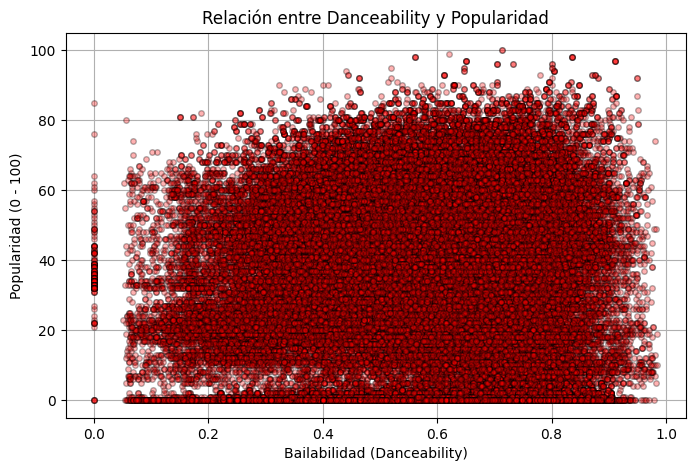

In [29]:
# Graficamos la característica 'danceability' (columna índice 2 de X) frente a popularidad
plotData(X[:, 2], y)

In [30]:
# Concatenamos las características originales con sus cuadrados (X^2)
X = np.concatenate([X, X * X], axis=1)

In [31]:

print("Matriz de características polinómicas (X, X^2):")
print(X)


Matriz de características polinómicas (X, X^2):
[[2.30666000e+05 0.00000000e+00 6.76000000e-01 ... 5.11225000e-01
  7.72939889e+03 1.60000000e+01]
 [1.49610000e+05 0.00000000e+00 4.20000000e-01 ... 7.12890000e-02
  6.00454512e+03 1.60000000e+01]
 [2.10826000e+05 0.00000000e+00 4.38000000e-01 ... 1.44000000e-02
  5.82657422e+03 1.60000000e+01]
 ...
 [2.71466000e+05 0.00000000e+00 6.29000000e-01 ... 5.52049000e-01
  1.75239349e+04 1.60000000e+01]
 [2.83893000e+05 0.00000000e+00 5.87000000e-01 ... 1.70569000e-01
  1.84851216e+04 1.60000000e+01]
 [2.41826000e+05 0.00000000e+00 5.26000000e-01 ... 5.01264000e-01
  6.27232320e+03 1.60000000e+01]]


In [32]:
def featureNormalize(X):
    """
    Normaliza las características en X calculando la media y desviación estándar.
    """
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    # Prevenir división por cero
    sigma[sigma == 0] = 1e-8

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [33]:
# Llama a featureNormalize con los datos polinómicos cargados
X_norm, mu, sigma = featureNormalize(X)

print('Media calculada por columna:\n', mu)
print('\nDesviación estándar calculada por columna:\n', sigma)
print('\nMatriz de datos normalizada:\n', X_norm)

Media calculada por columna:
 [ 2.28031153e+05  8.55007500e-02  5.66800643e-01  6.41383271e-01
  5.30912552e+00 -8.25894983e+00  6.37558224e-01  8.46523241e-02
  3.14906772e-01  1.56050923e-01  2.13554054e-01  4.74065951e-01
  1.22147695e+02  3.90403425e+00  6.35105499e+10  8.55007500e-02
  3.51379817e-01  4.74639342e-01  4.08602970e+01  9.35044668e+01
  6.37558224e-01  1.83453438e-02  2.09736389e-01  1.20175892e-01
  8.18488332e-02  2.91954233e-01  1.58187493e+04  1.54286441e+01]

Desviación estándar calculada por columna:
 [1.07295587e+05 2.79625413e-01 1.73542064e-01 2.51529009e-01
 3.55998360e+00 5.02933539e+00 4.80705456e-01 1.05732340e-01
 3.32520847e-01 3.09554521e-01 1.90377255e-01 2.59259921e-01
 2.99781583e+01 4.32620755e-01 2.49635520e+11 2.79625413e-01
 1.88717878e-01 2.92630502e-01 3.92040987e+01 1.42778266e+02
 4.80705456e-01 7.76703954e-02 3.00634671e-01 2.67354076e-01
 1.65531607e-01 2.61956472e-01 7.63016654e+03 2.68508962e+00]

Matriz de datos normalizada:
 [[ 0.02455

In [34]:
print(X_norm)

[[ 0.0245569  -0.30576888  0.62923855 ...  0.83705039 -1.06018006
   0.21278839]
 [-0.7308889  -0.30576888 -0.84590813 ... -0.84237366 -1.28623722
   0.21278839]
 [-0.16035285 -0.30576888 -0.74218688 ... -1.05954333 -1.30956186
   0.21278839]
 ...
 [ 0.40481485 -0.30576888  0.35841084 ...  0.99289308  0.22347947
   0.21278839]
 [ 0.52063508 -0.30576888  0.11639459 ... -0.4633794   0.34945139
   0.21278839]
 [ 0.12856863 -0.30576888 -0.23510521 ...  0.79902499 -1.25114256
   0.21278839]]


Despues de `featureNormalize` la funcion es provada, se añade el temino de interseccion a `X_norm`:

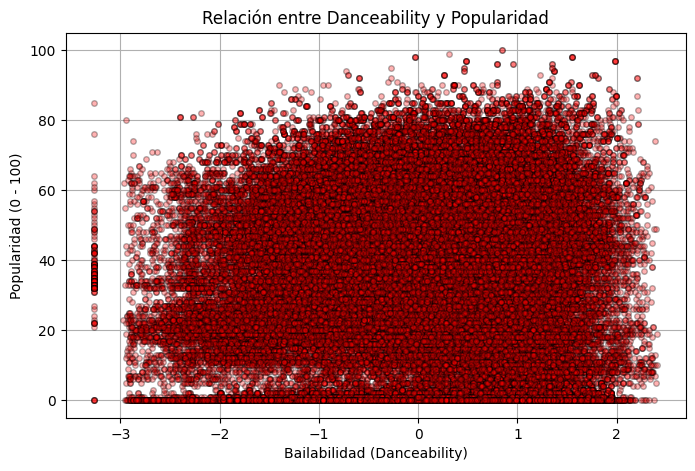

In [35]:
# Graficamos la columna normalizada de 'danceability' (columna índice 2)
plotData(X_norm[:, 2], y)

In [36]:
# Añade el término de intersección a X (Columna de unos para x0 = 1)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [37]:
print("Matriz de entrenamiento final X (con columna de unos x0=1):")
print(X)
print("\nDimensiones de X:", X.shape)

Matriz de entrenamiento final X (con columna de unos x0=1):
[[ 1.          0.0245569  -0.30576888 ...  0.83705039 -1.06018006
   0.21278839]
 [ 1.         -0.7308889  -0.30576888 ... -0.84237366 -1.28623722
   0.21278839]
 [ 1.         -0.16035285 -0.30576888 ... -1.05954333 -1.30956186
   0.21278839]
 ...
 [ 1.          0.40481485 -0.30576888 ...  0.99289308  0.22347947
   0.21278839]
 [ 1.          0.52063508 -0.30576888 ... -0.4633794   0.34945139
   0.21278839]
 [ 1.          0.12856863 -0.30576888 ...  0.79902499 -1.25114256
   0.21278839]]

Dimensiones de X: (113999, 29)


<a id="section5"></a>
### 2.2 Descenso por el gradiente

En la versión univariable únicamente contábamos con una variable de entrada. Ahora trabajamos con un modelo que combina 14 características reales de las canciones más sus 14 términos al cuadrado, sumando un total de $28$ características (o $29$ al incluir el término de intersección $x_0 = 1$).A pesar de tener muchas más características, la regla de actualización del descenso por el gradiente y la función de costo siguen siendo exactamente las mismas. La gran ventaja es que, utilizando operaciones matriciales en lugar de bucles manuales, el cálculo se realiza de forma inmediata sobre todo el conjunto de datos.Las funciones computeCostMulti y gradientDescentMulti se diseñaron de forma vectorial. Esto significa que pueden procesar cualquier número de columnas automáticamente mediante la propiedad .shape de los arreglos de numpy.

<div class="alert alert-block alert-warning">
**Nota de implementación:** En la regresión multivariable, el costo $J(\theta)$ mide el error cuadrático medio entre la popularidad predicha por el modelo y la popularidad real de las canciones. La representación matricial vectorizada se expresa como:

$$ J(\theta) = \frac{1}{2m}(X\theta - \vec{y})^T(X\theta - \vec{y}) $$

donde:

$$ X = \begin{pmatrix}
- (x^{(1)})^T - \\
- (x^{(2)})^T - \\
\vdots \\
- (x^{(m)})^T - \\ \\
\end{pmatrix} \qquad \mathbf{y} = \begin{bmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(m)} \\\end{bmatrix}$$

$X$ representa la matriz de características de las $m$ canciones ($113,999$ filas y $29$ columnas).$\mathbf{y}$ es el vector que contiene la popularidad real de cada canción.Aprovechar esta forma vectorizada en numpy nos permite calcular las predicciones y el error de miles de registros en una sola línea de código sin necesidad de usar ciclos for.
</div>

<a id="computeCostMulti"></a>

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [39]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0
    # Cálculo de las predicciones del modelo (hipótesis)
    h = np.dot(X, theta)
    # Cálculo de la función de costo (Error Cuadrático Medio)
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J



In [40]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
# Número de ejemplos de entrenamiento
    m = y.shape[0]

    # Copia de theta para evitar modificar la variable original
    theta = theta.copy()

    # Historial para almacenar los costos en cada iteración
    J_history = []

    for i in range(num_iters):
        # Cálculo del error (hipótesis - y)
        error = np.dot(X, theta) - y

        # Actualización vectorial de theta
        theta = theta - (alpha / m) * np.dot(X.T, error)

        # Almacenamiento del costo actual
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

#### 3.2.1 Seleccionando coheficientes de aprendizaje


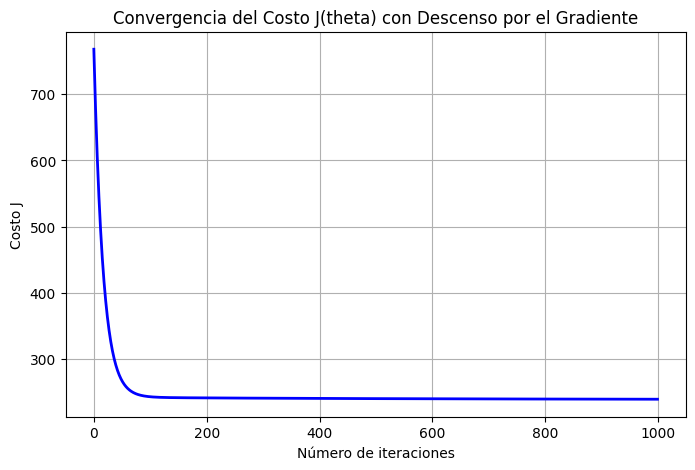

Costo final alcanzado: 239.3684
Vector theta calculado por el descenso por el gradiente:
[33.23882666 -0.11665623  0.51047281  3.70494008  1.59205283  0.1722419
  2.65098043 -0.1781842  -1.94628259  3.75792417 -2.0476404  -0.91652007
 -0.4185112   0.12418362 -0.12556407 -0.15162202  0.51047281 -2.79271689
 -2.65619743 -0.27140495  2.72041086 -0.1781842   0.44670287 -4.69782596
  0.04567262  1.22642568 -1.99234193  0.3195333   0.53326492]


In [41]:
# Selección de hiperparámetros
alpha = 0.03
num_iters = 1000

# Inicializa theta según la cantidad exacta de columnas de X (29 características en total)
theta = np.zeros(X.shape[1])

# Ejecuta el descenso por el gradiente
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia de la función de costo J(theta)
pyplot.figure(figsize=(8, 5))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='blue')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Costo J(theta) con Descenso por el Gradiente')
pyplot.grid(True)
pyplot.show()

# Muestra los parámetros theta calculados
print(f'Costo final alcanzado: {J_history[-1]:.4f}')
print('Vector theta calculado por el descenso por el gradiente:')
print(theta)

In [42]:
# Ejemplo de prueba con 14 características reales de una canción
# [duration_ms, explicit, danceability, energy, key, loudness, mode, speechiness, acousticness, instrumentalness, liveness, valence, tempo, time_signature]
cancion_ejemplo = np.array([210000, 0, 0.65, 0.80, 5, -5.5, 1, 0.05, 0.10, 0.00, 0.15, 0.60, 120.0, 4])

# 1. Elevamos al cuadrado y concatenamos para obtener exactamente 28 características polinómicas
cancion_poly = np.concatenate([cancion_ejemplo, cancion_ejemplo ** 2])

# 2. Normalizar usando la media (mu) y desviación estándar (sigma) guardadas
cancion_norm = (cancion_poly - mu) / sigma

# 3. Agregar el término de intersección x0 = 1 al inicio
cancion_final = np.concatenate([[1], cancion_norm])

# 4. Calcular la predicción mediante el producto punto (x * theta)
popularity_predicha = np.dot(cancion_final, theta)

print(f'Popularidad estimada de la canción (usando Descenso por el Gradiente): {popularity_predicha:.2f} / 100')

Popularidad estimada de la canción (usando Descenso por el Gradiente): 34.67 / 100


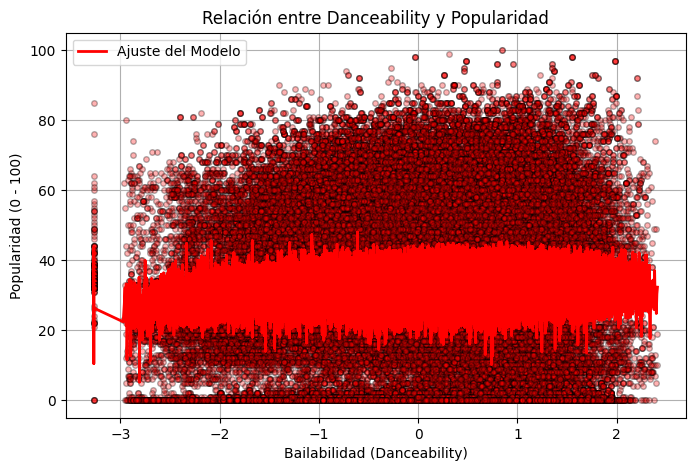

In [43]:
# Graficamos la característica 'danceability' (columna índice 3 en la matriz X con unos) frente a la popularidad real
plotData(X[:, 3], y)

# Ordenamos los puntos de la característica para trazar la curva de predicción de forma continua
indices_ordenados = np.argsort(X[:, 3])
pyplot.plot(X[indices_ordenados, 3], np.dot(X, theta)[indices_ordenados], 'r-', lw=2, label='Ajuste del Modelo')
pyplot.legend()
pyplot.show()

In [44]:
# Vector de características base de una canción de prueba (14 valores)
cancion_ejemplo = np.array([210000, 0, 0.65, 0.80, 5, -5.5, 1, 0.05, 0.10, 0.00, 0.15, 0.60, 120.0, 4])

# Concatenamos los valores originales con sus cuadrados (obteniendo 28 valores)
X_array = np.concatenate([cancion_ejemplo, cancion_ejemplo ** 2])

# Normalizamos las 28 características usando la media y desviación estándar del entrenamiento
X_array[0:28] = (X_array[0:28] - mu) / sigma

# Agregamos la columna de intersección x0 = 1 al inicio
X_array = np.concatenate([[1], X_array])

In [45]:
X_array[1:29]
print(f"Popularidad estimada para la canción (usando Descenso por el Gradiente): {np.dot(X_array, theta):.2f} / 100")

Popularidad estimada para la canción (usando Descenso por el Gradiente): 34.67 / 100


<a id="section7"></a>
### 2.3 Ecuacion de la Normal

La Ecuación de la Normal es un método matemático directo que nos permite encontrar los valores óptimos de los parámetros $\theta$ en un solo paso, utilizando la siguiente fórmula matricial:

$$ \theta = \left( X^T X\right)^{-1} X^T\vec{y}$$

La principal ventaja de este método es que no requiere normalizar ni escalar ninguna característica, y tampoco necesita elegir una tasa de aprendizaje ($\alpha$) ni un número de iteraciones. No hay "pasos" ni "bucles de entrenamiento" como en el descenso por el gradiente; la solución exacta se obtiene directamente mediante álgebra lineal.

Para aplicarlo en el cuadernillo:

Volvemos a cargar los datos originales de las canciones desde dataset.csv para trabajar con sus valores en escala real (sin restar la media ni dividir entre la desviación estándar).

Generamos las características polinómicas ($X$ y $X^2$).

Le agregamos únicamente la columna de unos al inicio ($x_0 = 1$) para incluir el término de intersección ($\theta_0$).

In [47]:
# Cargar datos
# data = np.loadtxt(os.path.join('Datasets', 'ex1data2.txt'), delimiter=',')
data = '/content/drive/MyDrive/InteligenciaArtificial/dataset.csv'
df = pd.read_csv(data, sep=',')

# Conversión de columna booleana 'explicit' a entero (0 o 1)
df['explicit'] = df['explicit'].astype(int)

# Selección de las 14 características numéricas
feature_cols = [
    'duration_ms', 'explicit', 'danceability', 'energy', 'key',
    'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature'
]

X_raw = df[feature_cols].values
y = df['popularity'].values
m = y.size

# Generación de características polinómicas (X y X^2)
X_poly = np.concatenate([X_raw, X_raw ** 2], axis=1)

# Se almacena la matriz sin columna de unos por control
X_original = X_poly.copy()

# Se añade la columna de unos (x0 = 1) para la Ecuación de la Normal (SIN normalizar)
X_normal_eq = np.concatenate([np.ones((m, 1)), X_poly], axis=1)

print(f"Número de ejemplos (m): {m}")
print(f"Dimensiones de X para la Ecuación de la Normal: {X_normal_eq.shape}")

Número de ejemplos (m): 114000
Dimensiones de X para la Ecuación de la Normal: (114000, 29)


In [48]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    # Uso de np.linalg.pinv para asegurar la reversibilidad matricial
    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)

    return theta

In [49]:
# Cálculo de parámetros mediante la Ecuación de la Normal
theta_normal = normalEqn(X_normal_eq, y)

# Muestra los resultados obtenidos a partir de la aplicación de la ecuación de the normal
print('Theta calculado a partir de la ecuación de la normal:')
print(theta_normal)

Theta calculado a partir de la ecuación de la normal:
[ 1.46132835e-08  9.36825204e-05  2.11101898e-09  7.80635143e-09
  1.21176324e-08  7.83731422e-08 -6.53718733e-08  1.03506653e-08
  1.79507536e-09  2.57276669e-09 -1.08025611e-10  3.10710759e-09
  9.84369104e-09  3.58831059e-06  5.76177305e-08 -2.73266061e-11
  2.11101898e-09  4.35841230e-09  1.02769866e-08  6.10417607e-07
  2.08305574e-07  1.03506653e-08  2.48123080e-10  1.30297135e-09
 -2.50283588e-10  9.00643925e-10  6.93328866e-09  6.98953174e-04
  2.26116609e-07]


In [50]:
# Características originales de una canción de prueba (14 valores)
# [duration_ms, explicit, danceability, energy, key, loudness, mode, speechiness, acousticness, instrumentalness, liveness, valence, tempo, time_signature]
cancion_ejemplo = np.array([210000, 0, 0.65, 0.80, 5, -5.5, 1, 0.05, 0.10, 0.00, 0.15, 0.60, 120.0, 4])

# 1. Expandir a características polinómicas (X y X^2) en su escala original (SIN normalizar)
X_array = np.concatenate([cancion_ejemplo, cancion_ejemplo ** 2])

# 2. Agregar el término de intersección x0 = 1 al inicio (obteniendo los 29 elementos)
X_array_final = np.concatenate([[1], X_array])

# 3. Calcular la predicción mediante el producto punto con theta
popularidad_estimada = np.dot(X_array_final, theta_normal)

print(f'Popularidad estimada de la canción (usando la Ecuación de la Normal): {popularidad_estimada:.2f} / 100')

Popularidad estimada de la canción (usando la Ecuación de la Normal): 28.53 / 100


In [51]:
# Re-extraemos X e y del DataFrame limpio (df) para asegurar que ambos tengan 113,999 filas
X_raw = df[feature_cols].values
y = df['popularity'].values
m = y.size

# Re-generamos la matriz X polinómica y normalizada
X_poly = np.concatenate([X_raw, X_raw ** 2], axis=1)
X_norm, mu, sigma = featureNormalize(X_poly)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

# Ahora ambas matrices miden exactamente 113,999 filas
print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

Dimensión de X: (114000, 29)
Dimensión de y: (114000,)


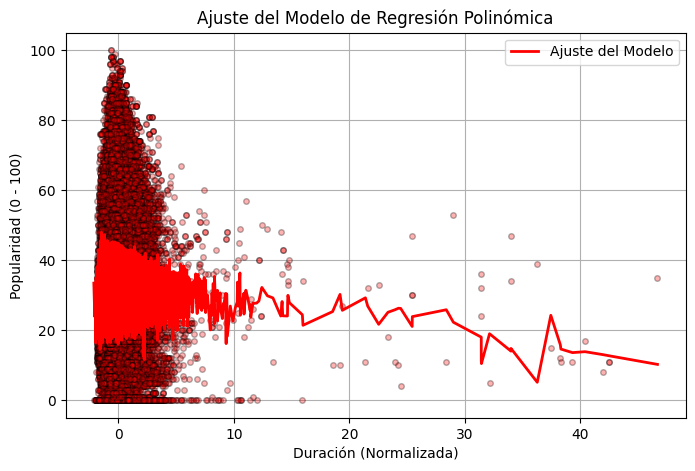

In [52]:
# Graficar los puntos dispersos de la primera característica (duration_ms) frente a la popularidad
plotData(X[:, 1], y)

# Ordenar los índices para trazar la curva ajustada por el modelo de forma continua
indices_ordenados = np.argsort(X[:, 1])

# Graficar la línea de predicción ajustada por el vector theta
pyplot.plot(X[indices_ordenados, 1], np.dot(X, theta)[indices_ordenados], 'r-', lw=2, label='Ajuste del Modelo')
pyplot.xlabel('Duración (Normalizada)')
pyplot.ylabel('Popularidad (0 - 100)')
pyplot.title('Ajuste del Modelo de Regresión Polinómica')
pyplot.legend()
pyplot.show()

In [53]:
# ==============================================================================
# DEMOSTRACIÓN DE EFECTIVIDAD: EVALUACIÓN DE 100 PREDICCIONES DE PRUEBA
# ==============================================================================

num_predicciones = 100

# 1. Seleccionamos las primeras 100 muestras reales del dataset
X_test_raw = X_raw[:num_predicciones, :]
y_test_real = y[:num_predicciones]

# 2. Generamos las características polinómicas (X y X^2) para el test
X_test_poly = np.concatenate([X_test_raw, X_test_raw ** 2], axis=1)

# ------------------------------------------------------------------------------
# A) Predicciones con Descenso por el Gradiente (requiere datos normalizados)
# ------------------------------------------------------------------------------
X_test_norm = (X_test_poly - mu) / sigma
X_test_grad = np.concatenate([np.ones((num_predicciones, 1)), X_test_norm], axis=1)
y_pred_grad = np.dot(X_test_grad, theta)

# ------------------------------------------------------------------------------
# B) Predicciones con Ecuación de la Normal (con datos en escala original)
# ------------------------------------------------------------------------------
X_test_norm_eq = np.concatenate([np.ones((num_predicciones, 1)), X_test_poly], axis=1)
y_pred_norm = np.dot(X_test_norm_eq, theta_normal)

# ------------------------------------------------------------------------------
# C) Mostrar tabla comparativa de los primeros 15 resultados
# ------------------------------------------------------------------------------
print(f"{'N°':<5} | {'Popularidad Real':<18} | {'Predicción (Gradiente)':<24} | {'Predicción (Ecuación Normal)':<25}")
print("-" * 80)
for i in range(15):
    print(f"{i+1:<5} | {y_test_real[i]:<18.2f} | {y_pred_grad[i]:<24.2f} | {y_pred_norm[i]:<25.2f}")

# ------------------------------------------------------------------------------
# D) Cálculo del error absoluto medio (MAE) sobre las 100 predicciones
# ------------------------------------------------------------------------------
mae_grad = np.mean(np.abs(y_test_real - y_pred_grad))
mae_norm = np.mean(np.abs(y_test_real - y_pred_norm))

print("-" * 80)
print(f"Error Absoluto Medio (Gradiente): {mae_grad:.2f} puntos")
print(f"Error Absoluto Medio (Ecuación de la Normal): {mae_norm:.2f} puntos")

N°    | Popularidad Real   | Predicción (Gradiente)   | Predicción (Ecuación Normal)
--------------------------------------------------------------------------------
1     | 73.00              | 32.57                    | 25.56                    
2     | 55.00              | 31.91                    | 17.60                    
3     | 57.00              | 37.90                    | 22.61                    
4     | 71.00              | 31.81                    | 40.89                    
5     | 82.00              | 39.65                    | 27.61                    
6     | 58.00              | 34.45                    | 25.53                    
7     | 74.00              | 34.33                    | 34.01                    
8     | 80.00              | 35.10                    | 37.08                    
9     | 74.00              | 36.16                    | 28.61                    
10    | 56.00              | 38.49                    | 22.46                    
11    | 74.00 